# 03 — Análisis de Negocio e Insights

**Objetivo:** explorar la capa Gold a través de los KPIs ya construidos
(`gold.vw_*`), visualizarlos, e interpretar qué dicen del negocio.

Este notebook consume directamente las 14 vistas de KPIs (`sql/gold/kpis/`),
no recalcula ninguna métrica desde cero -- así el número que ves acá es
exactamente el mismo que vería un dashboard o cualquier otra herramienta que
consulte las mismas vistas.

Estructura: por cada dominio (university, billing, crm) se muestra el
gráfico y, debajo, una celda para anotar el hallazgo en palabras propias.
Esa interpretación es la que alimenta la Fase 14 (generación de insights) y
la Fase 15 (presentación ejecutiva).


In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import psycopg2

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
pd.set_option("display.max_columns", 50)

def get_connection():
    return psycopg2.connect(
        host=os.environ.get("WAREHOUSE_HOST", "postgres-warehouse"),
        port=os.environ.get("WAREHOUSE_PORT", "5432"),
        dbname=os.environ.get("WAREHOUSE_DB", "warehouse"),
        user=os.environ.get("WAREHOUSE_USER", "rodrick"),
        password=os.environ.get("WAREHOUSE_PASSWORD", "rodrick123"),
    )

conn = get_connection()
print("Conexión OK.")


Conexión OK.


---
## Dominio: `university`

### Desempeño por curso — `gold.vw_course_performance`

In [2]:
course_perf = pd.read_sql("SELECT * FROM gold.vw_course_performance ORDER BY avg_score DESC", conn)
course_perf.head(10)


/tmp/ipykernel_9504/3895111210.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  course_perf = pd.read_sql("SELECT * FROM gold.vw_course_performance ORDER BY avg_score DESC", conn)


,course_id,course_name,department,professor_name,total_grades,avg_score,approval_rate_pct
0,CRS-00141,Course 00141,cs,Manuel Arancibia,190,77.3,94.2
1,CRS-00010,Course 00010,cs,Manuel Tapia,275,77.0,92.7
2,CRS-00263,Course 00263,math,Catalina Vera,177,76.7,91.0
3,CRS-00022,Course 00022,literature,Luis Hernandez,143,76.7,91.6
4,CRS-00084,Course 00084,cs,Emilia Carrasco,197,76.7,91.4
5,CRS-00035,Course 00035,biology,Martina Rodriguez,188,76.7,91.0
6,CRS-00194,Course 00194,biology,Catalina Araya,202,76.6,91.1
7,CRS-00283,Course 00283,economics,Matias Sandoval,158,76.6,91.8
8,CRS-00126,Course 00126,biology,Catalina Munoz,206,76.6,92.2
9,CRS-00110,Course 00110,cs,Rodrigo Sandoval,190,76.4,93.7


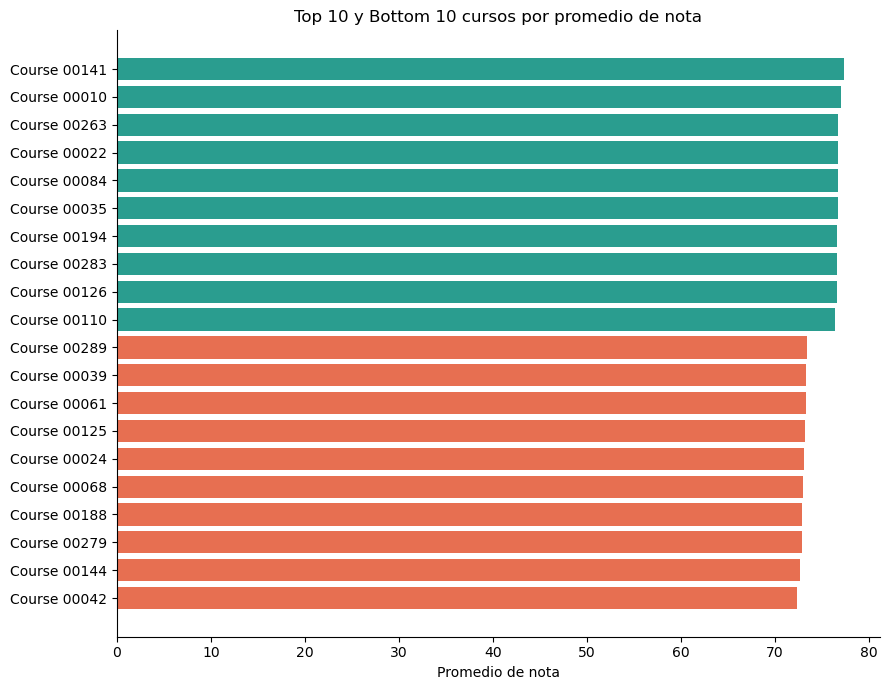

In [3]:
top_bottom = pd.concat([course_perf.head(10), course_perf.tail(10)])
fig, ax = plt.subplots(figsize=(9, 7))
colors = ["#2a9d8f" if x in course_perf.head(10)["course_name"].values else "#e76f51" for x in top_bottom["course_name"]]
ax.barh(top_bottom["course_name"], top_bottom["avg_score"], color=colors)
ax.set_xlabel("Promedio de nota")
ax.set_title("Top 10 y Bottom 10 cursos por promedio de nota")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


**Hallazgo — desempeño por curso:**
_(completa aquí: ¿hay una brecha grande entre los mejores y peores cursos?
¿se concentran en algún departamento o profesor en particular?)_


### Inscripciones por semestre — `gold.vw_enrollments_by_semester`

In [4]:
enroll_sem = pd.read_sql("SELECT * FROM gold.vw_enrollments_by_semester", conn)
enroll_sem


/tmp/ipykernel_9504/3682421378.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  enroll_sem = pd.read_sql("SELECT * FROM gold.vw_enrollments_by_semester", conn)


,semester_id,semester_code,year,half,total_enrollments,distinct_students
0,SEM-001,2022-1,2022,1,3164,2346
1,SEM-002,2022-2,2022,2,3199,2365
2,SEM-003,2023-1,2023,1,3143,2309
3,SEM-004,2023-2,2023,2,3014,2246
4,SEM-005,2024-1,2024,1,3076,2287
5,SEM-006,2024-2,2024,2,3108,2333
6,SEM-007,2025-1,2025,1,3110,2336
7,SEM-008,2025-2,2025,2,3186,2357


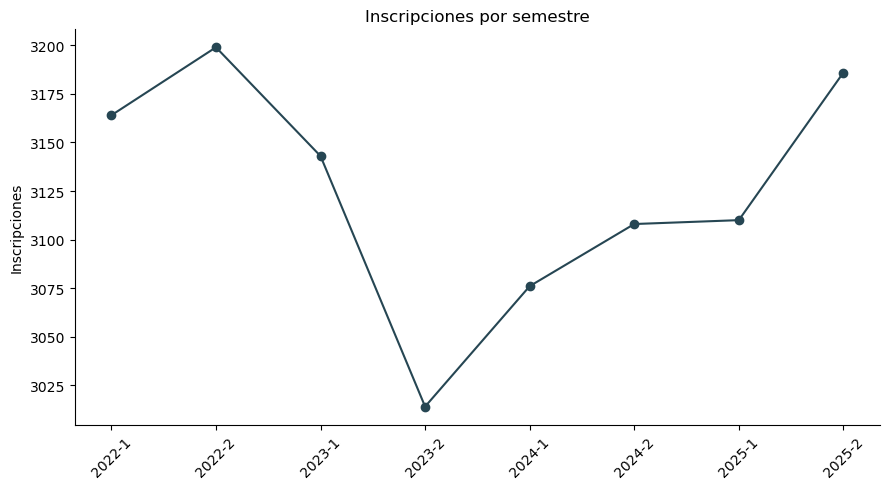

In [5]:
fig, ax = plt.subplots()
ax.plot(enroll_sem["semester_code"], enroll_sem["total_enrollments"], marker="o", color="#264653")
ax.set_ylabel("Inscripciones")
ax.set_title("Inscripciones por semestre")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Hallazgo — tendencia de inscripciones:**
_(completa aquí: ¿la demanda crece, decrece, o se mantiene estable en el tiempo?)_


### Calidad de datos — edad al inscribirse (`gold.vw_data_quality_students`)

In [6]:
dq_students = pd.read_sql("SELECT * FROM gold.vw_data_quality_students", conn)
dq_students


/tmp/ipykernel_9504/3532814245.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  dq_students = pd.read_sql("SELECT * FROM gold.vw_data_quality_students", conn)


,total_students,invalid_age_count,invalid_age_pct
0,5000,636,12.72


**Nota de transparencia:** este KPI no mide desempeño de negocio, mide la
calidad del propio dataset -- qué porcentaje de estudiantes tiene una edad
implausible registrada al momento de inscribirse (ver docs/decisiones.md,
sección de discovery, para el detalle de por qué se decidió marcar en vez de
descartar estas filas).


---
## Dominio: `billing`

### Revenue por producto — `gold.vw_revenue_by_product`

/tmp/ipykernel_9504/3894977298.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  rev_product = pd.read_sql("SELECT * FROM gold.vw_revenue_by_product", conn)


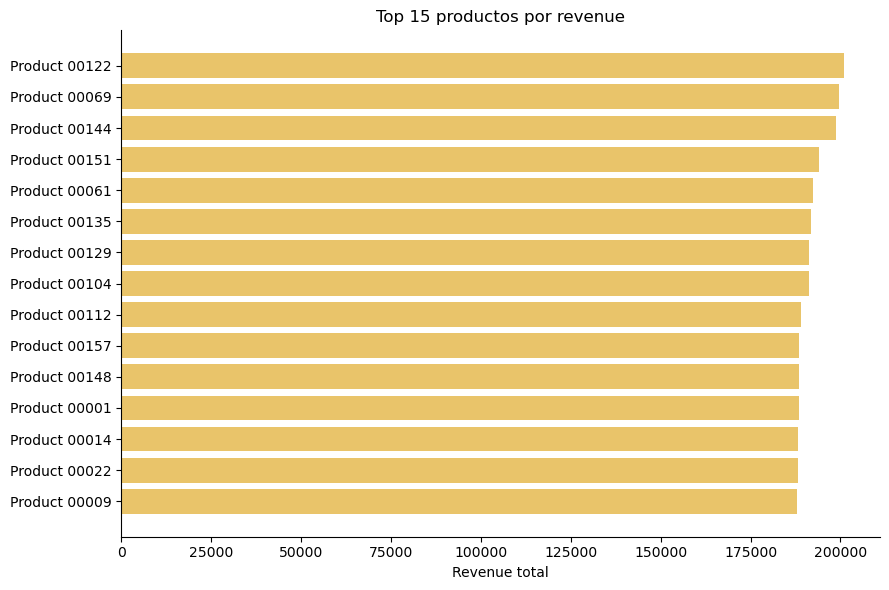

In [7]:
rev_product = pd.read_sql("SELECT * FROM gold.vw_revenue_by_product", conn)
top15 = rev_product.head(15)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top15["product_name"], top15["total_revenue"], color="#e9c46a")
ax.set_xlabel("Revenue total")
ax.set_title("Top 15 productos por revenue")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


**Hallazgo — revenue por producto:**
_(completa aquí: ¿el revenue está concentrado en pocos productos, o repartido
parejo? ¿qué categoría domina?)_


### Revenue por segmento de cliente — `gold.vw_revenue_by_segment`

/tmp/ipykernel_9504/2151799187.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  rev_segment = pd.read_sql("SELECT * FROM gold.vw_revenue_by_segment", conn)


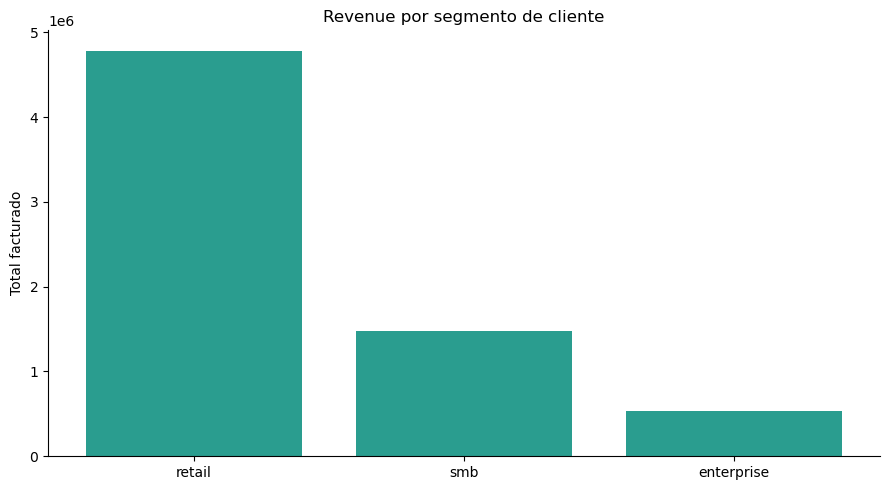

In [8]:
rev_segment = pd.read_sql("SELECT * FROM gold.vw_revenue_by_segment", conn)

fig, ax = plt.subplots()
ax.bar(rev_segment["segment"], rev_segment["total_invoiced"], color="#2a9d8f")
ax.set_ylabel("Total facturado")
ax.set_title("Revenue por segmento de cliente")
plt.tight_layout()
plt.show()


**Hallazgo — segmentos:**
_(completa aquí: ¿qué segmento aporta más? ¿tiene sentido invertir más
esfuerzo comercial ahí?)_


### Cobranza — `gold.vw_collection_rate` y `gold.vw_avg_days_to_pay`

In [9]:
collection = pd.read_sql("SELECT * FROM gold.vw_collection_rate", conn)
days_to_pay = pd.read_sql("SELECT * FROM gold.vw_avg_days_to_pay", conn)
print(collection)
print(days_to_pay)


/tmp/ipykernel_9504/1369812041.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  collection = pd.read_sql("SELECT * FROM gold.vw_collection_rate", conn)
/tmp/ipykernel_9504/1369812041.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  days_to_pay = pd.read_sql("SELECT * FROM gold.vw_avg_days_to_pay", conn)


   total_collected  total_invoiced  collection_rate_pct
0       6493684.72     13349666.33                 48.6
   avg_days_to_pay
0             22.6


**Hallazgo — cobranza:**
_(completa aquí: ¿qué porcentaje de lo facturado se cobra? ¿el tiempo
promedio de pago es razonable para el flujo de caja del negocio?)_


### Churn de suscripciones — `gold.vw_subscription_churn` y `gold.vw_data_quality_subscriptions`

In [10]:
churn = pd.read_sql("SELECT * FROM gold.vw_subscription_churn", conn)
dq_subs = pd.read_sql("SELECT * FROM gold.vw_data_quality_subscriptions", conn)
print(churn)
print(dq_subs)


   total_subscriptions  ended_subscriptions  churn_rate_pct
0                15000                15000           100.0
   total_subscriptions  invalid_range_count  invalid_range_pct
0                15000                  783               5.22


/tmp/ipykernel_9504/3546809259.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  churn = pd.read_sql("SELECT * FROM gold.vw_subscription_churn", conn)
/tmp/ipykernel_9504/3546809259.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  dq_subs = pd.read_sql("SELECT * FROM gold.vw_data_quality_subscriptions", conn)


**Hallazgo — churn:**
_(completa aquí: ¿la tasa de churn es alta? recuerda que este cálculo no
distingue entre "canceló" y "terminó su plan naturalmente" -- ambos casos
cuentan como end_date no nulo)_


---
## Dominio: `crm`

### Win rate — `gold.vw_win_rate`

In [11]:
win_rate = pd.read_sql("SELECT * FROM gold.vw_win_rate", conn)
win_rate


/tmp/ipykernel_9504/3117342762.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  win_rate = pd.read_sql("SELECT * FROM gold.vw_win_rate", conn)


,won_count,lost_count,win_rate_pct
0,476,303,61.1


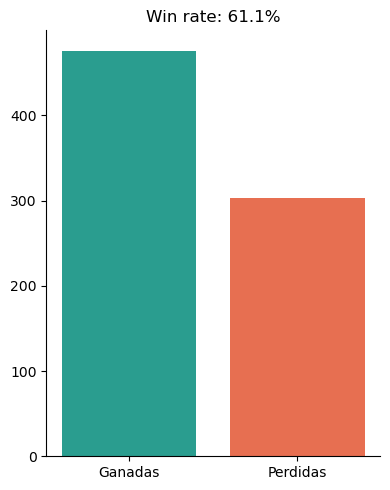

In [12]:
fig, ax = plt.subplots(figsize=(4, 5))
ax.bar(["Ganadas", "Perdidas"], [win_rate["won_count"][0], win_rate["lost_count"][0]],
       color=["#2a9d8f", "#e76f51"])
ax.set_title(f"Win rate: {win_rate['win_rate_pct'][0]}%")
plt.tight_layout()
plt.show()


**Hallazgo — win rate:**
_(completa aquí: ¿es un win rate saludable? nota que solo se cuentan
oportunidades en estado terminal -- ¿qué % del total de oportunidades sigue
abierto? revisa vw_pipeline_value para eso)_


### Pipeline abierto — `gold.vw_pipeline_value`

In [13]:
pipeline = pd.read_sql("SELECT * FROM gold.vw_pipeline_value", conn)
pipeline


/tmp/ipykernel_9504/1404003928.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pipeline = pd.read_sql("SELECT * FROM gold.vw_pipeline_value", conn)


,stage,opportunity_count,total_amount
0,qualification,611,23040966.86
1,prospect,621,22829672.15
2,proposal,569,22222895.05
3,negotiation,420,15370881.80


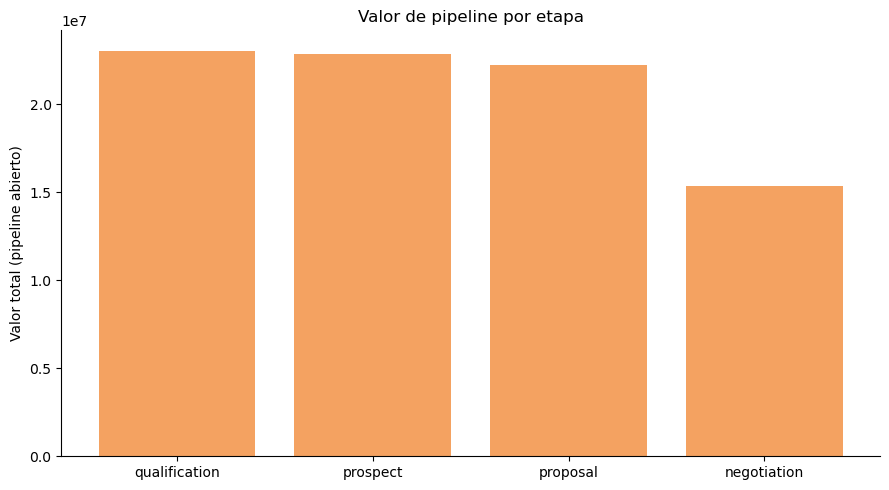

In [14]:
fig, ax = plt.subplots()
ax.bar(pipeline["stage"], pipeline["total_amount"], color="#f4a261")
ax.set_ylabel("Valor total (pipeline abierto)")
ax.set_title("Valor de pipeline por etapa")
plt.tight_layout()
plt.show()


**Hallazgo — pipeline:**
_(completa aquí: ¿en qué etapa se concentra más valor? ¿eso sugiere un
cuello de botella en el proceso de ventas?)_


### Duración del ciclo de venta — `gold.vw_sales_cycle_duration`

In [15]:
cycle = pd.read_sql("SELECT * FROM gold.vw_sales_cycle_duration", conn)
cycle


/tmp/ipykernel_9504/4268080176.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  cycle = pd.read_sql("SELECT * FROM gold.vw_sales_cycle_duration", conn)


,avg_days_to_close,opportunities_included,opportunities_total,pct_included
0,577.7,1971,3000,65.7


**Nota de calidad de datos, no ocultar en la presentación:** este cálculo
excluye las oportunidades donde `close_date < created_at` (~34% del total,
ver docs/decisiones.md). El campo `pct_included` de esta vista muestra
exactamente qué porcentaje de las oportunidades sí se usó para el promedio.

**Hallazgo — duración del ciclo:**
_(completa aquí, con el número real de avg_days_to_close)_


### Actividades por resultado — `gold.vw_activities_by_outcome`

In [16]:
activities_outcome = pd.read_sql("SELECT * FROM gold.vw_activities_by_outcome", conn)
activities_outcome


/tmp/ipykernel_9504/1330507586.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  activities_outcome = pd.read_sql("SELECT * FROM gold.vw_activities_by_outcome", conn)


,stage,total_activities,opportunities_with_activity,avg_activities_per_opportunity
0,prospect,2143,599,3.6
1,qualification,2075,589,3.5
2,lost,997,291,3.4
3,negotiation,1351,403,3.4
4,proposal,1894,552,3.4
5,won,1555,461,3.4


**Hallazgo — actividades vs. resultado:**
_(completa aquí: ¿las oportunidades ganadas tuvieron más actividades en
promedio que las perdidas? ¿eso sugiere que más esfuerzo comercial
correlaciona con éxito?)_


---
## Resumen consolidado de insights (Fase 14)

Consolida aquí, en una lista, los 3-5 hallazgos más importantes de todo el
notebook -- los que realmente le dirías a un gerente en 2 minutos. Prioriza
por impacto de negocio, no por lo interesante que sea técnicamente.

1.
2.
3.

Estos puntos son el insumo directo para la Fase 15 (presentación ejecutiva).


In [17]:
print(churn)
print(dq_subs)

   total_subscriptions  ended_subscriptions  churn_rate_pct
0                15000                15000           100.0
   total_subscriptions  invalid_range_count  invalid_range_pct
0                15000                  783               5.22


In [18]:
status_check = pd.read_sql("""
    SELECT status, COUNT(*) AS n,
           SUM(CASE WHEN end_date IS NOT NULL THEN 1 ELSE 0 END) AS con_end_date
    FROM gold.fact_subscriptions
    GROUP BY status
""", conn)
status_check

/tmp/ipykernel_9504/3571485050.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  status_check = pd.read_sql("""


,status,n,con_end_date
0,active,11272,11272
1,paused,1486,1486
2,cancelled,2242,2242
